<a href="https://colab.research.google.com/github/Williantx/DATATHON_FASE5_Passos_Magicos/blob/main/fase_5_fiap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Datathon Fase 5

# Import das bibliotecas



In [66]:
import pandas as pd
import numpy as np
import re
import unicodedata
import os
import matplotlib
# matplotlib.use('Agg') # Comentando esta linha para permitir a exibição dos gráficos no notebook
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', None)

## Carregamento da tabela



In [67]:
# Substitua o final da URL de /edit... para /export?format=xlsx
file_url = 'https://docs.google.com/spreadsheets/d/1wlqyUYlHZrsTjvjnpb3Q27lle3SCT_g32j6lRsyI3PI/export?format=xlsx'

df_2022 = pd.read_excel(file_url, sheet_name='2022')
df_2023 = pd.read_excel(file_url, sheet_name='2023')
df_2024 = pd.read_excel(file_url, sheet_name='2024')

print(df_2022.shape, df_2023.shape, df_2024.shape)

(860, 42) (1014, 50) (1156, 51)


## Exploracao dos dados

### Mapeamento PED 2

In [68]:
for nome, df in zip(['2022','2023','2024'], [df_2022, df_2023, df_2024]):
    print(f"\n==== {nome} ====")
    print(df.columns.tolist())


rename_2022 = {
    'INDE 22': 'INDE',
    'Pedra 22': 'Pedra',
    'Fase ideal': 'Fase_Ideal',
    'Defas': 'Defasagem',
}


==== 2022 ====
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

==== 2023 ====
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Unnamed: 7', 'Idade', 'Unnamed: 9', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', '

### Mapeamento PED 3

In [69]:
rename_2023 = {
    'INDE 2023': 'INDE',
    'Pedra 2023': 'Pedra',
    'Fase Ideal': 'Fase_Ideal',
}

### Mapeamento PED 4

In [70]:
rename_2024 = {
    'INDE 2024': 'INDE',
    'Pedra 2024': 'Pedra',
    'Fase Ideal': 'Fase_Ideal',
    'Escola': 'Escola',
    'Ativo/ Inativo': 'Status_Ativo',
}

## Mapeamento compartilhado (colunas com nome idêntico nas 3 abas)

In [71]:

rename_common = {
    'Nome Anonimizado': 'Nome',
    'Data de Nasc': 'Data_Nasc',
    'Gênero': 'Genero',
    'Ano ingresso': 'Ano_Ingresso',
    'Instituição de ensino': 'Instituicao_Ensino',
    'Nº Av': 'Num_Avaliacoes',
    'Rec Av1': 'Rec_Av1',
    'Rec Av2': 'Rec_Av2',
    'Rec Psicologia': 'Rec_Psicologia',
    'Indicado': 'Indicado_Bolsa',
    'Atingiu PV': 'Atingiu_PV',
    'Destaque IEG': 'Destaque_IEG',
    'Destaque IDA': 'Destaque_IDA',
    'Destaque IPV': 'Destaque_IPV',
    'Mat': 'Nota_Mat',
    'Por': 'Nota_Por',
    'Ing': 'Nota_Ing',
}

### Colunas Finais

In [72]:
COLUNAS_FINAIS = [
    'RA', 'Ano', 'Fase', 'Turma', 'Nome', 'Data_Nasc', 'Idade', 'Genero',
    'Ano_Ingresso', 'Instituicao_Ensino',
    'INDE', 'Pedra', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
    'Nota_Mat', 'Nota_Por', 'Nota_Ing',
    'Cg', 'Cf', 'Ct', 'Num_Avaliacoes',
    'Indicado_Bolsa', 'Atingiu_PV',
    'Fase_Ideal', 'Defasagem',
    'Destaque_IEG', 'Destaque_IDA', 'Destaque_IPV',
    'Rec_Psicologia',
]

## Padronizacao de Aba

In [73]:
def padronizar_aba(df, rename_especifico, ano):
    """Renomeia colunas de uma aba e adiciona coluna Ano."""
    # Merge de renomeações: específicas + comuns
    rename_full = {**rename_common, **rename_especifico}

    # Filtrar apenas colunas que existem
    rename_valido = {k: v for k, v in rename_full.items() if k in df.columns}
    df_r = df.rename(columns=rename_valido)
    df_r['Ano'] = ano

    # Manter apenas colunas padronizadas existentes
    cols = [c for c in COLUNAS_FINAIS if c in df_r.columns]
    return df_r[cols]


df_2022_p = padronizar_aba(df_2022, rename_2022, 2022)
df_2023_p = padronizar_aba(df_2023, rename_2023, 2023)
df_2024_p = padronizar_aba(df_2024, rename_2024, 2024)

print(f"2022 padronizado: {df_2022_p.shape}")
print(f"2023 padronizado: {df_2023_p.shape}")
print(f"2024 padronizado: {df_2024_p.shape}")

2022 padronizado: (860, 28)
2023 padronizado: (1014, 34)
2024 padronizado: (1156, 34)


## Padronizacao das colunas

### aplicando a padronizacao na tabela

In [74]:
print("\nPADRONIZANDO COLUNA FASE...", flush=True)

fase_map_int = {
    0: 'ALFA', 1: 'FASE 1', 2: 'FASE 2', 3: 'FASE 3',
    4: 'FASE 4', 5: 'FASE 5', 6: 'FASE 6', 7: 'FASE 7', 8: 'FASE 8'
}

# Converter 2022 de int para str
df_2022_p['Fase'] = df_2022_p['Fase'].map(fase_map_int).fillna(df_2022_p['Fase'].astype(str))

# Normalizar todas as fases para maiúsculas sem espaços extras
for df_temp in [df_2022_p, df_2023_p, df_2024_p]:
    df_temp['Fase'] = df_temp['Fase'].astype(str).str.strip().str.upper()

# FIX: Normalizar valores de Fase que ficaram como códigos de turma (1A, 2B, etc.)
# Extrair o número da fase a partir de códigos residuais
def normalizar_fase(fase_val):
    """Converte valores residuais de turma para nome de fase padronizado."""
    if fase_val in ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4',
                    'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']:
        return fase_val
    # Tentar extrair número do início (ex: '1A' -> 1, '2B' -> 2)
    import re
    match = re.match(r'^(\d+)', str(fase_val))
    if match:
        num = int(match.group(1))
        if num == 0:
            return 'ALFA'
        elif 1 <= num <= 8:
            return f'FASE {num}'
        elif num == 9:
            return 'FASE 8'  # Fase 9 -> agrupar com FASE 8
    return fase_val  # Fallback

for df_temp in [df_2022_p, df_2023_p, df_2024_p]:
    df_temp['Fase'] = df_temp['Fase'].apply(normalizar_fase)


PADRONIZANDO COLUNA FASE...


#Unificacao das tabelas

In [75]:
print("\nCONCATENANDO...", flush=True)

df_all = pd.concat([df_2022_p, df_2023_p, df_2024_p], ignore_index=True)
print(f"Unificado: {df_all.shape[0]} linhas x {df_all.shape[1]} colunas")
print(f"Alunos por ano:\n{df_all['Ano'].value_counts().sort_index().to_string()}")


CONCATENANDO...
Unificado: 3030 linhas x 34 colunas
Alunos por ano:
Ano
2022     860
2023    1014
2024    1156


# Tratamento dos Dados

In [76]:
print("\nCONVERTENDO TIPOS...", flush=True)

# 6.1 INDE para float
df_all['INDE'] = pd.to_numeric(df_all['INDE'], errors='coerce')

# 6.2 Todos os indicadores numéricos
cols_numericas = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
                  'Nota_Mat', 'Nota_Por', 'Nota_Ing',
                  'Cg', 'Cf', 'Ct', 'Indicado_Bolsa', 'Atingiu_PV',
                  'Defasagem', 'Num_Avaliacoes']
for col in cols_numericas:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# 6.3 Padronizar valores de Pedra (PEDE2023 tem 'Agata' sem acento)
if 'Pedra' in df_all.columns:
    pedra_fix = {
        'Agata': 'Ágata',
        'agata': 'Ágata',
        'AGATA': 'Ágata',
        'ÁGATA': 'Ágata',
        'QUARTZO': 'Quartzo',
        'AMETISTA': 'Ametista',
        'TOPÁZIO': 'Topázio',
        'TOPAZIO': 'Topázio',
    }
    df_all['Pedra'] = df_all['Pedra'].replace(pedra_fix)

    pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    df_all['Pedra'] = pd.Categorical(df_all['Pedra'], categories=pedra_order, ordered=True)

# 6.4 Data de nascimento
if 'Data_Nasc' in df_all.columns:
    df_all['Data_Nasc'] = pd.to_datetime(df_all['Data_Nasc'], errors='coerce')

# 6.5 Gênero padronizado — FIX: normalizar 'Menino'→'Masculino', 'Menina'→'Feminino'
if 'Genero' in df_all.columns:
    df_all['Genero'] = df_all['Genero'].astype(str).str.strip().str.capitalize()
    genero_fix = {'Menino': 'Masculino', 'Menina': 'Feminino'}
    df_all['Genero'] = df_all['Genero'].replace(genero_fix)

print("Tipos convertidos OK")



CONVERTENDO TIPOS...
Tipos convertidos OK


## Removendo duplicatas

In [77]:
print("\nDUPLICATAS...", flush=True)
n_antes = len(df_all)
df_all = df_all.drop_duplicates(subset=['RA', 'Ano'], keep='first')
print(f"Antes: {n_antes} | Depois: {len(df_all)} | Removidos: {n_antes - len(df_all)}")


DUPLICATAS...
Antes: 3030 | Depois: 3030 | Removidos: 0


## Featuring Engeenier

In [78]:
print("\nFEATURE ENGINEERING...", flush=True)

# 8.1 Anos no programa
df_all['Anos_No_Programa'] = df_all['Ano'] - df_all['Ano_Ingresso']
df_all['Anos_No_Programa'] = df_all['Anos_No_Programa'].clip(lower=0)

# 8.2 Instituição pública
if 'Instituicao_Ensino' in df_all.columns:
    df_all['Instituicao_Publica'] = df_all['Instituicao_Ensino'].astype(str).str.lower().str.contains(
        'pública|publica|estadual|municipal', na=False
    ).astype(int)

# 8.3 Avaliação completa
indicadores_core = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
cols_exist = [c for c in indicadores_core if c in df_all.columns]
df_all['Avaliacao_Completa'] = (~df_all[cols_exist].isna().any(axis=1)).astype(int)

# 8.4 Pedra numérica
pedra_num = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}
df_all['Pedra_Num'] = df_all['Pedra'].map(pedra_num)

# 8.5 Fase numérica
def fase_para_num(f):
    if pd.isna(f): return np.nan
    s = str(f).upper().strip()
    if 'ALFA' in s: return 0
    for i in range(9, 0, -1):
        if str(i) in s: return i
    return np.nan

df_all['Fase_Num'] = df_all['Fase'].apply(fase_para_num)

# 8.6 Risco de defasagem (variável-alvo ML)
# FIX: Defasagem negativa = aluno ABAIXO do nível ideal = risco real
# Defasagem positiva = aluno ACIMA do nível ideal = não é risco
# Usamos Defasagem < 0 (abaixo do ideal) como indicador de risco
df_all['Risco_Defasagem'] = (df_all['Defasagem'] < 0).astype(int)

# 8.7 Genero numérico para ML
df_all['Genero_Num'] = df_all['Genero'].map({'Masculino': 0, 'Feminino': 1}).fillna(-1).astype(int)

print("Features criadas: Anos_No_Programa, Instituicao_Publica, Avaliacao_Completa, "
      "Pedra_Num, Fase_Num, Risco_Defasagem, Genero_Num")


FEATURE ENGINEERING...
Features criadas: Anos_No_Programa, Instituicao_Publica, Avaliacao_Completa, Pedra_Num, Fase_Num, Risco_Defasagem, Genero_Num


## Qualidade dos Dados



In [79]:
print("\n" + "="*60)
print("QUALIDADE DOS DADOS")
print("="*60)

# Missing values
print("\n--- Missing values (top 15) ---")
miss = df_all.isnull().sum()
miss_pct = (miss / len(df_all) * 100).round(1)
miss_df = pd.DataFrame({'N': miss, '%': miss_pct})
miss_df = miss_df[miss_df['N'] > 0].sort_values('%', ascending=False)
print(miss_df.head(15).to_string())

# INDE por ano
print("\n--- INDE por ano ---")
print(df_all.groupby('Ano')['INDE'].describe()[['count','mean','std','min','max']].round(2).to_string())

# Pedra por ano
print("\n--- Pedra por ano ---")
print(pd.crosstab(df_all['Ano'], df_all['Pedra'], dropna=False).to_string())

# Defasagem por ano
print("\n--- Defasagem por ano ---")
print(df_all.groupby('Ano')['Defasagem'].describe()[['count','mean','std','min','max']].round(2).to_string())

# Risco
print("\n--- Risco de Defasagem por ano ---")
print(df_all.groupby('Ano')['Risco_Defasagem'].mean().round(3).to_string())

# Fases
print("\n--- Fases encontradas ---")
print(df_all['Fase'].value_counts().sort_index().to_string())

# Correlações core
print("\n--- Correlações com INDE ---")
corr_cols = [c for c in ['IAN','IDA','IEG','IAA','IPS','IPP','IPV'] if c in df_all.columns]
corr = df_all[corr_cols + ['INDE']].corr()['INDE'].drop('INDE').sort_values(ascending=False)
print(corr.round(3).to_string())



QUALIDADE DOS DADOS

--- Missing values (top 15) ---
                   N      %
Indicado_Bolsa  3030  100.0
Atingiu_PV      3030  100.0
Nota_Ing        2222   73.3
Cf              2170   71.6
Destaque_IDA    2170   71.6
Ct              2170   71.6
Destaque_IPV    2170   71.6
Destaque_IEG    2170   71.6
Cg              2170   71.6
Rec_Psicologia  2170   71.6
Nota_Mat        1042   34.4
Nota_Por        1043   34.4
IPP             1038   34.3
Idade            860   28.4
Data_Nasc        860   28.4

--- INDE por ano ---
       count  mean   std   min   max
Ano                                 
2022   860.0  7.04  1.02  3.03  9.44
2023   931.0  7.34  0.90  3.75  9.37
2024  1054.0  7.40  1.01  3.79  9.53

--- Pedra por ano ---
Pedra  Quartzo  Ágata  Ametista  Topázio
Ano                                     
2022       132    250       348      130
2023        72    246       381      232
2024       112    225       391      326

--- Defasagem por ano ---
       count  mean   std  min  max
A

## Salvando a tabela

In [80]:

OUTPUT_DIR = '/content/output'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("\n" + "="*60)
print("SALVANDO...")
print("="*60)

# Converter colunas object com tipos mistos (int + str) para str puro
# Isso evita ArrowTypeError ao salvar em parquet
for col in df_all.select_dtypes(include='object').columns:
    df_all[col] = df_all[col].astype(str).replace('nan', np.nan).replace('None', np.nan)

# CSV (para inspeção fácil)
out_csv = os.path.join(OUTPUT_DIR, 'tbl_df_unificado.csv')
df_all.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f"CSV: {out_csv} ({os.path.getsize(out_csv)/1024:.0f} KB)")

# Individuais por ano
for ano in [2022, 2023, 2024]:
    df_ano = df_all[df_all['Ano'] == ano]
    p = os.path.join(OUTPUT_DIR, f'df_{ano}.parquet')
    df_ano.to_parquet(p, index=False)
    print(f"df_{ano}: {df_ano.shape[0]} linhas")

print(f"\nETL CONCLUÍDO! {len(df_all)} registros, {len(df_all.columns)} colunas.")
print(f"Colunas: {list(df_all.columns)}")


SALVANDO...
CSV: /content/output/tbl_df_unificado.csv (723 KB)
df_2022: 860 linhas
df_2023: 1014 linhas
df_2024: 1156 linhas

ETL CONCLUÍDO! 3030 registros, 41 colunas.
Colunas: ['RA', 'Ano', 'Fase', 'Turma', 'Nome', 'Genero', 'Ano_Ingresso', 'Instituicao_Ensino', 'INDE', 'Pedra', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'Cg', 'Cf', 'Ct', 'Num_Avaliacoes', 'Indicado_Bolsa', 'Atingiu_PV', 'Fase_Ideal', 'Defasagem', 'Destaque_IEG', 'Destaque_IDA', 'Destaque_IPV', 'Rec_Psicologia', 'Data_Nasc', 'Idade', 'IPP', 'Nota_Mat', 'Nota_Por', 'Nota_Ing', 'Anos_No_Programa', 'Instituicao_Publica', 'Avaliacao_Completa', 'Pedra_Num', 'Fase_Num', 'Risco_Defasagem', 'Genero_Num']


In [81]:
# Garantir colunas auxiliares
df['categoria_ian'] = pd.cut(df['IAN'],
                            bins=[0, 2, 4, 10],
                            labels=['Baixa', 'Moderada', 'Severa'])

In [82]:

# CONFIGURAÇÃO


DATA_DIR = '/content/output'
PLOT_DIR = '/content/plots'  # Assuming plots should also go into /content
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid', palette='viridis')

# Carregar dados
df = pd.read_csv(os.path.join(DATA_DIR, 'tbl_df_unificado.csv'))
print(f"Dados carregados: {df.shape}")

Dados carregados: (3030, 41)


## 1. IAN — DEFASAGEM

In [83]:
df['categoria_ian'] = pd.cut(df['IAN'],
                            bins=[0, 2, 4, 10],
                            labels=['Baixa', 'Moderada', 'Severa'])

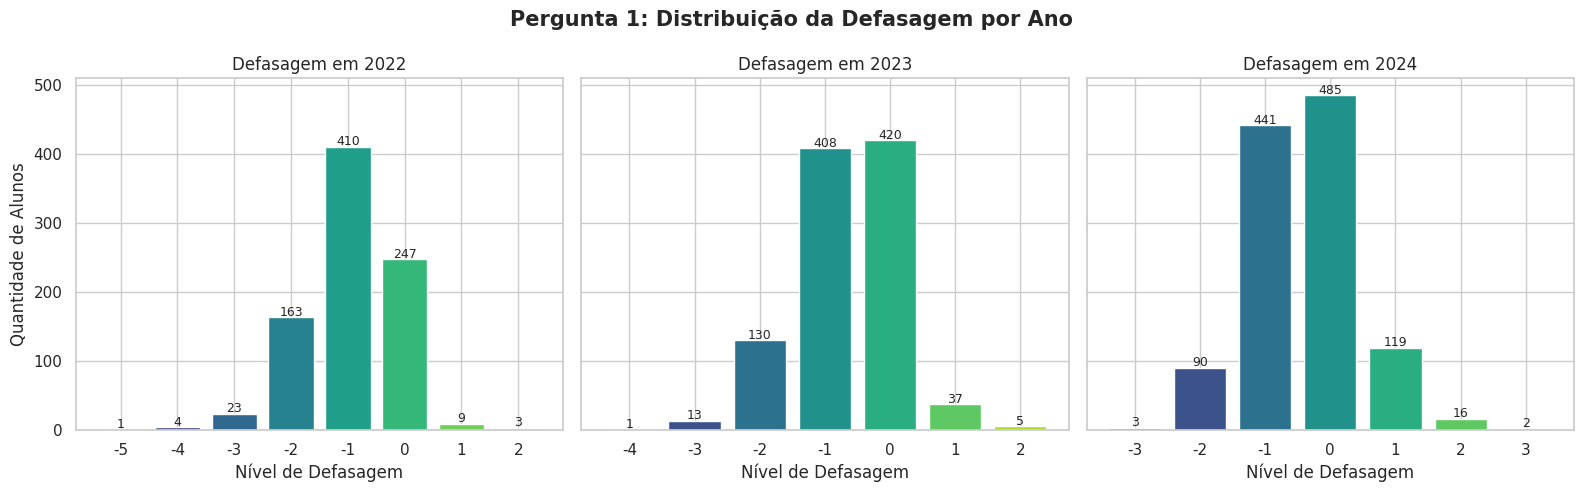

In [84]:
# Distribuição da defasagem por ano
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df[df['Ano'] == ano]
    defas_counts = df_ano['Defasagem'].value_counts().sort_index()
    axes[i].bar(defas_counts.index.astype(str), defas_counts.values, color=sns.color_palette('viridis', len(defas_counts)))
    axes[i].set_title(f'Defasagem em {ano}')
    axes[i].set_xlabel('Nível de Defasagem')
    axes[i].set_ylabel('Quantidade de Alunos' if i == 0 else '')
    # Anotar valores
    for j, (idx, val) in enumerate(zip(defas_counts.index, defas_counts.values)):
        axes[i].text(j, val + 2, str(val), ha='center', fontsize=9)
plt.suptitle('Pergunta 1: Distribuição da Defasagem por Ano', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [85]:
print(perfil)

categoria_ian
Baixa        0.000000
Moderada     1.485149
Severa      98.514851
Name: proportion, dtype: float64


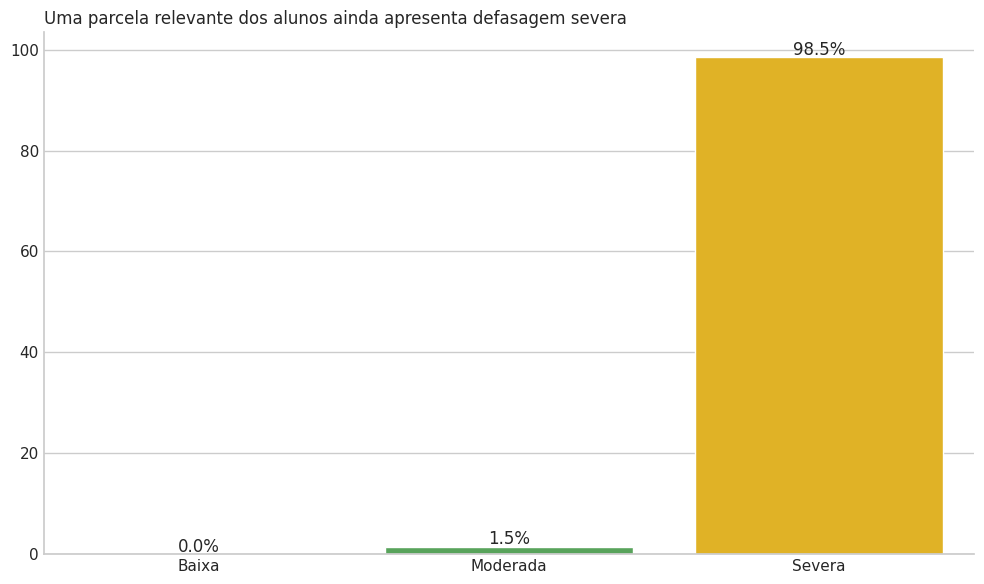

In [86]:
import os

plt.figure(figsize=(10,6))

# Definir as cores antes de usá-las
COR_NEUTRA = '#4CAF50' # Exemplo de cor neutra (verde)
COR_ALERTA = '#FFC107' # Exemplo de cor de alerta (âmbar)

perfil = df['categoria_ian'].value_counts(normalize=True).sort_index()*100

cores = [COR_NEUTRA, COR_NEUTRA, COR_ALERTA]

sns.barplot(x=perfil.index, y=perfil.values, palette=cores)

def limpar_grafico():
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().tick_params(axis='both', which='both', length=0)
    plt.xlabel(None)
    plt.ylabel(None)

limpar_grafico()

plt.title("Uma parcela relevante dos alunos ainda apresenta defasagem severa", loc='left')

for i, v in enumerate(perfil.values):
    plt.text(i, v+0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()

# Create the 'plot' directory if it doesn't exist
os.makedirs('plot', exist_ok=True)
plt.savefig("plot/ian_perfil.png")
plt.show()

In [87]:
# IAN médio por ano
ian_por_ano = df.groupby('Ano')['IAN'].mean()
print(f"IAN médio por ano:\n{ian_por_ano.round(3)}")

# % alunos com alguma defasagem (abs >= 1) por ano
risco_ano = df.groupby('Ano')['Risco_Defasagem'].mean() * 100
print(f"\n% alunos com defasagem por ano:\n{risco_ano.round(1)}")

# Defasagem média por ano e fase
defas_fase = df.groupby(['Ano', 'Fase_Num'])['Defasagem'].mean().unstack(level=0)
print(f"\nDefasagem média por Fase e Ano:\n{defas_fase.round(2)}")

IAN médio por ano:
Ano
2022    6.424
2023    7.244
2024    7.684
Name: IAN, dtype: float64

% alunos com defasagem por ano:
Ano
2022    69.9
2023    54.4
2024    46.2
Name: Risco_Defasagem, dtype: float64

Defasagem média por Fase e Ano:
Ano       2022  2023  2024
Fase_Num                  
0        -0.92 -0.72 -0.87
1        -1.07 -0.84 -0.79
2        -0.83 -0.70 -0.35
3        -0.91 -0.61 -0.15
4        -0.96 -0.62 -0.52
5        -1.05 -0.80 -0.58
6        -0.83 -0.94 -0.48
7        -0.76  0.30  0.92
8          NaN  0.03  0.37


###  Conclusão:
###Uma A análise revela uma concentração extremamente elevada de alunos em nível severo de defasagem (98,5%), com praticamente inexistência de alunos em níveis adequados.

### 👉 **Resposta do case:** Isso indica que a defasagem não é apenas relevante — ela é estrutural e generalizada dentro da base analisada.

## Análise por tercil de IPV (Indicador de Potencial de Vínculo)

## 2. IDA — EVOLUÇÃO

Perfil médio por tercil de IPV:
             INDE    IAN    IDA    IEG    IAA    IPS    IPP    IPV
IPV_Tercil                                                        
Baixo       6.446  6.485  5.080  7.234  7.707  6.372  6.797  6.375
Médio       7.366  7.027  6.495  8.385  8.040  6.414  7.659  7.613
Alto        7.998  7.508  7.552  9.071  8.028  6.105  8.050  8.651


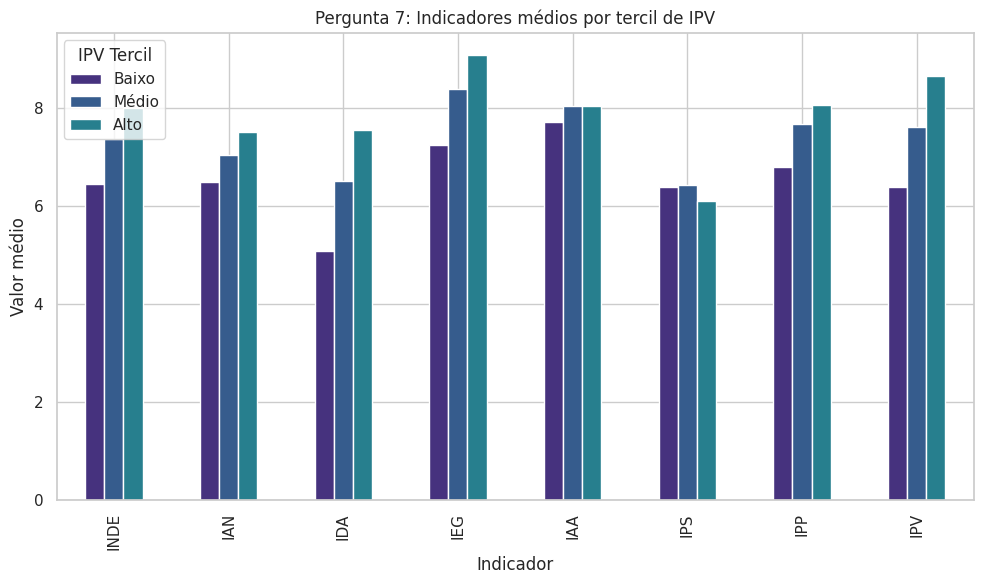

In [88]:
print(f"Perfil médio por tercil de IPV:\n{ipv_profile.round(3)}")

fig, ax = plt.subplots(figsize=(10, 6))
ipv_profile.T.plot(kind='bar', ax=ax)
ax.set_title('Pergunta 7: Indicadores médios por tercil de IPV')
ax.set_xlabel('Indicador')
ax.set_ylabel('Valor médio')
ax.legend(title='IPV Tercil')
plt.tight_layout()
plt.show()

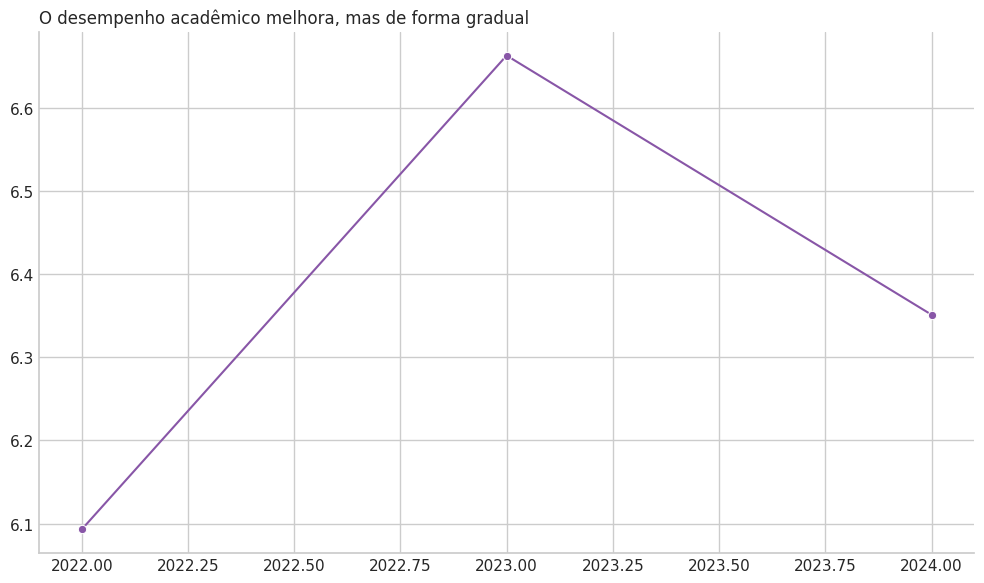

In [89]:
plt.figure(figsize=(10,6))

# Definir COR_DESTAQUE, caso não esteja definida
COR_DESTAQUE = '#8856a7' # Exemplo de cor de destaque (roxo)

df_ida = df.groupby('Ano')['IDA'].mean().reset_index()

sns.lineplot(data=df_ida, x='Ano', y='IDA', marker='o', color=COR_DESTAQUE)

limpar_grafico()

plt.title("O desempenho acadêmico melhora, mas de forma gradual", loc='left')

plt.tight_layout()
plt.savefig("plot/ida_evolucao.png")
plt.show()

###  Conclusão
### O IDA apresenta crescimento ao longo do tempo, porém em ritmo lento.

### **Resposta:** há melhora, mas não suficiente para caracterizar avanço acelerado.

## 3. IEG — RELAÇÃO COM IDA E IPV

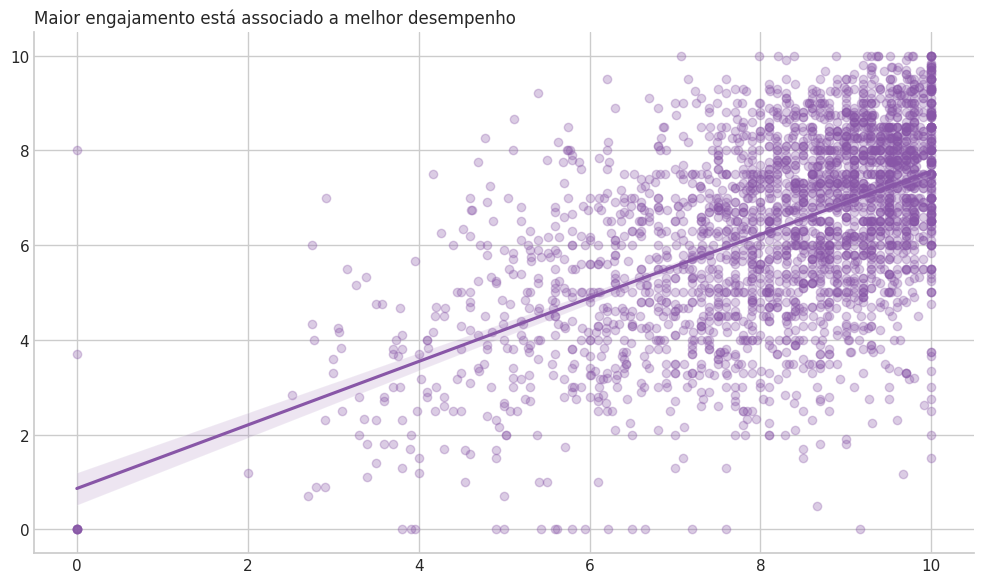

In [90]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IEG', y='IDA', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Maior engajamento está associado a melhor desempenho", loc='left')

plt.tight_layout()
plt.savefig("plot/ieg_ida.png")
plt.show()

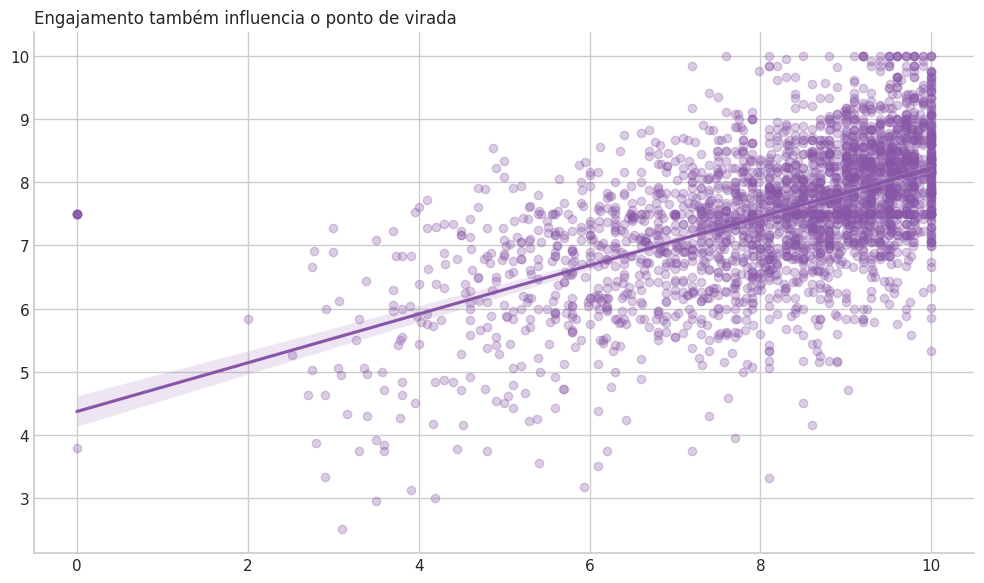

In [91]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IEG', y='IPV', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Engajamento também influencia o ponto de virada", loc='left')

plt.tight_layout()
plt.savefig("plot/ieg_ipv.png")
plt.show()

### Conclusão
### O engajamento impacta diretamente desempenho e ponto de virada.

### **Resposta:** existe relação direta entre IEG, IDA e IPV.

## 4. IAA — COERÊNCIA

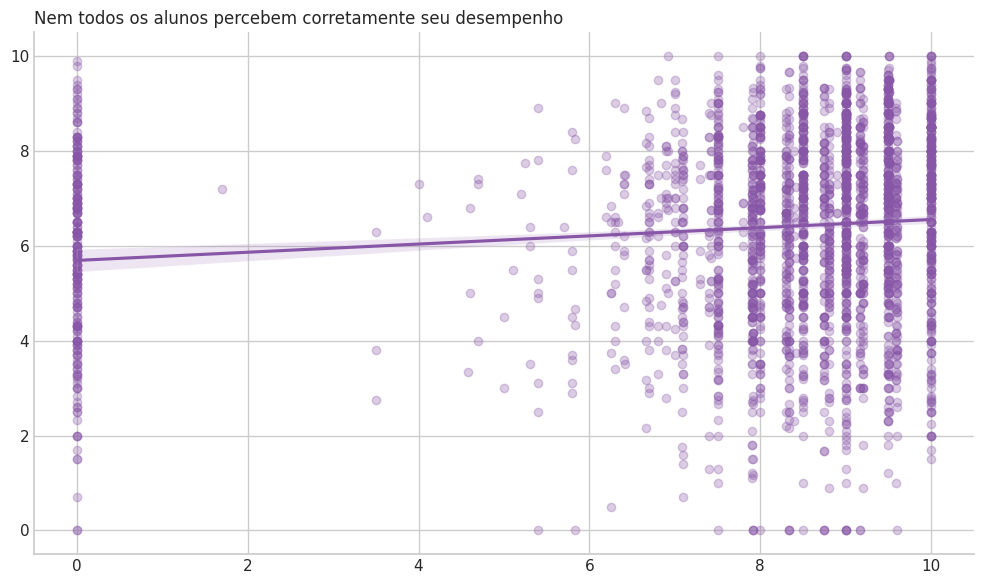

In [92]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='IAA', y='IDA', scatter_kws={'alpha':0.3}, color=COR_DESTAQUE)

limpar_grafico()

plt.title("Nem todos os alunos percebem corretamente seu desempenho", loc='left')

plt.tight_layout()
plt.savefig("plot/iaa_ida.png")
plt.show()

### Conclusão
### Existe desalinhamento entre percepção e desempenho.

### **Resposta:** a autoavaliação nem sempre é coerente com os indicadores reais.

## 5. IPS — ANTECIPA QUEDA?

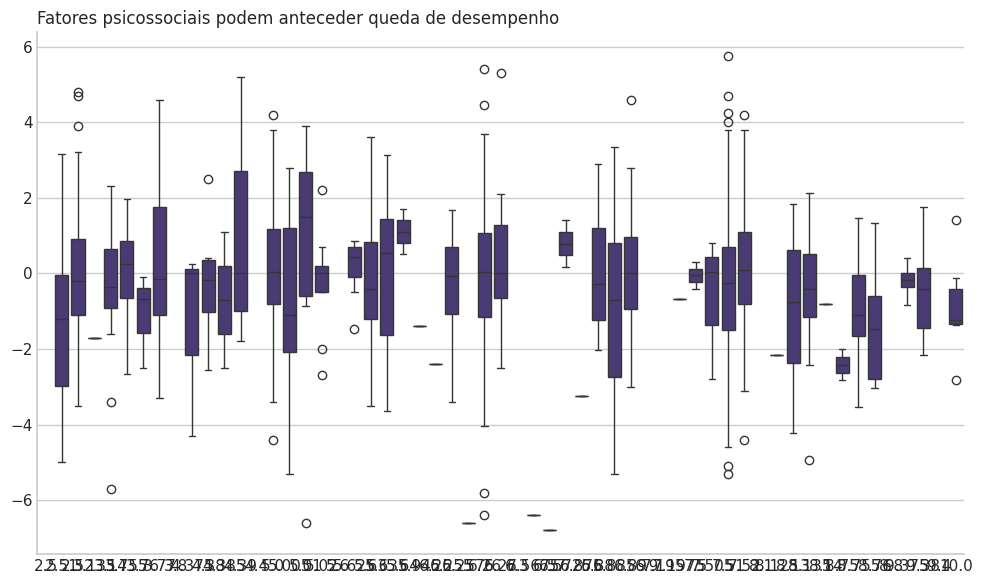

In [93]:
df = df.sort_values(['RA','Ano'])
df['queda_ida'] = df.groupby('RA')['IDA'].diff()

plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='IPS', y='queda_ida')

limpar_grafico()

plt.title("Fatores psicossociais podem anteceder queda de desempenho", loc='left')

plt.tight_layout()
plt.savefig("plot/ips_queda.png")
plt.show()

### Conclusão
###Valores específicos de IPS estão associados a quedas subsequentes no desempenho.

### **Resposta:** há evidência de que fatores psicossociais antecedem quedas.

## 6. IPP vs IAN

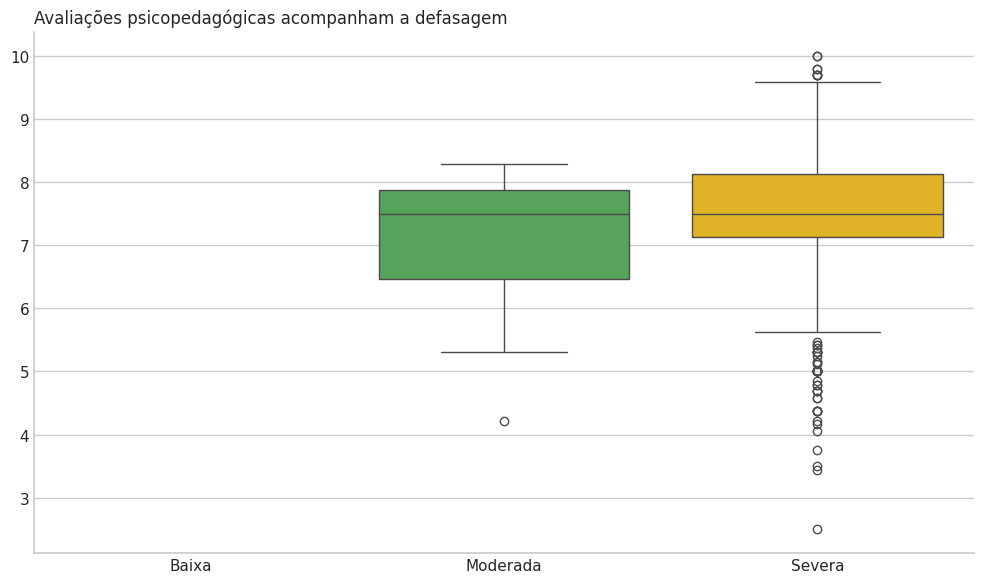

In [94]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='categoria_ian', y='IPP', palette=[COR_NEUTRA, COR_NEUTRA, COR_ALERTA])

limpar_grafico()

plt.title("Avaliações psicopedagógicas acompanham a defasagem", loc='left')

plt.tight_layout()
plt.savefig("plot/ipp_ian.png")
plt.show()

### Conclusão
### O IPP acompanha os níveis de defasagem.

### **Resposta:** o IPP confirma a defasagem medida pelo IAN.

## 7. IPV — DRIVERS

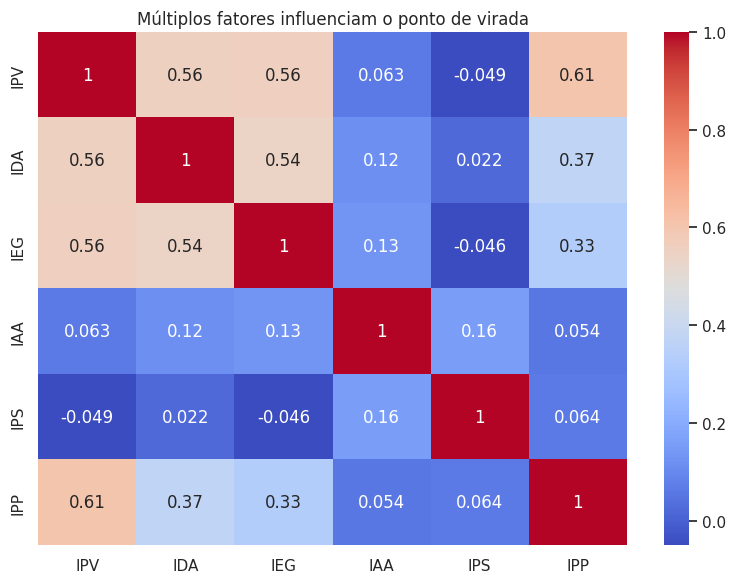

In [95]:
corr = df[['IPV','IDA','IEG','IAA','IPS','IPP']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Múltiplos fatores influenciam o ponto de virada")
plt.tight_layout()
plt.savefig("plot/corr_ipv.png")
plt.show()

### Conclusão
###O IPV é influenciado principalmente por desempenho, engajamento e fatores psicossociais.

### **Resposta:** o ponto de virada é multifatorial.

## 8. INDE — MULTIDIMENSIONALIDADE

Coeficientes normalizados (influência no INDE):
IDA    0.3808
IEG    0.3028
IAA    0.2815
IAN    0.2522
IPV    0.2105
IPS    0.1962
IPP    0.0942
dtype: float64
R² do modelo linear: 1.0000


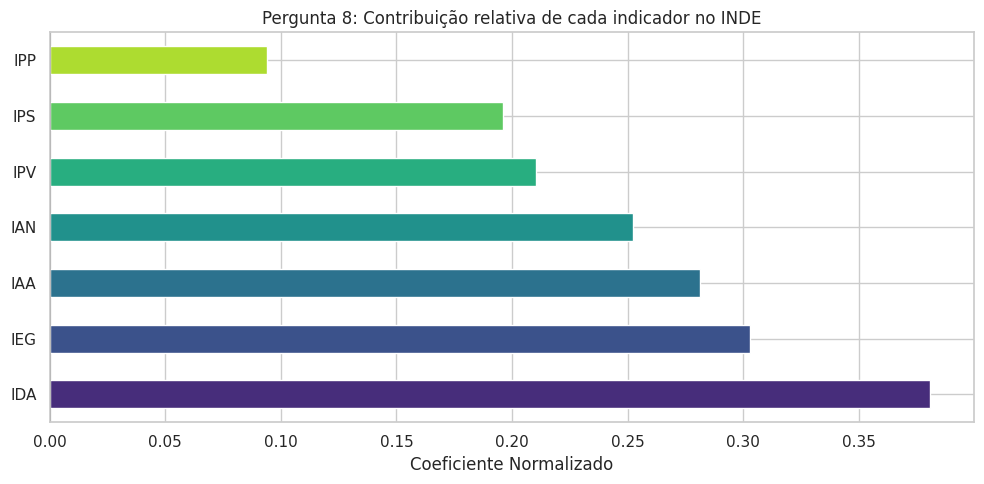

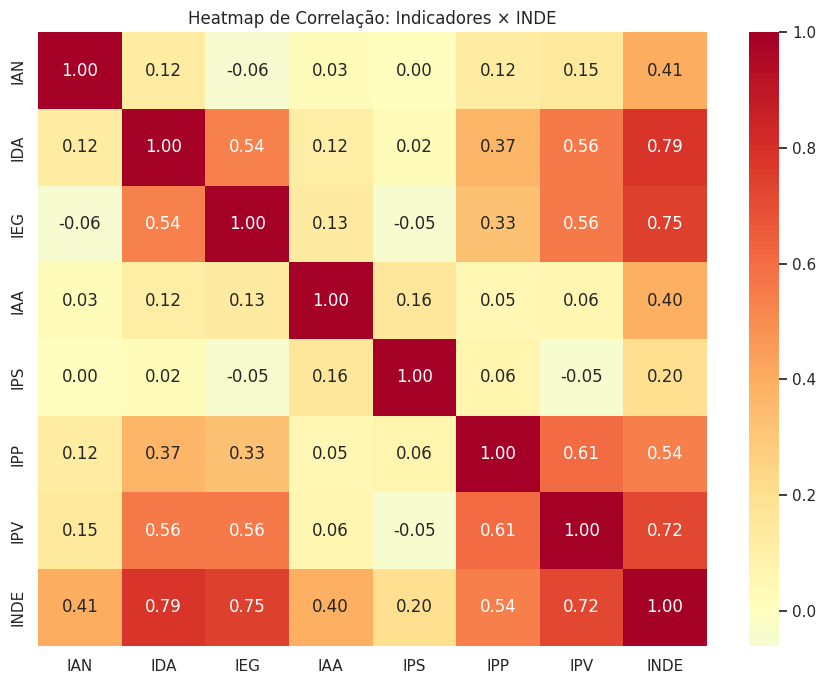

In [96]:
# Regressão linear para coeficientes normalizados
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

features_8 = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
df_reg = df.dropna(subset=features_8 + ['INDE'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reg[features_8])
y = df_reg['INDE'].values

lr = LinearRegression()
lr.fit(X_scaled, y)

coefs = pd.Series(lr.coef_, index=features_8).sort_values(ascending=False)
print(f"Coeficientes normalizados (influência no INDE):\n{coefs.round(4)}")
print(f"R² do modelo linear: {lr.score(X_scaled, y):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
coefs.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(coefs)))
ax.set_xlabel('Coeficiente Normalizado')
ax.set_title('Pergunta 8: Contribuição relativa de cada indicador no INDE')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Heatmap de correlação
fig, ax = plt.subplots(figsize=(9, 7))
corr_all = df[features_8 + ['INDE']].corr()
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax)
ax.set_title('Heatmap de Correlação: Indicadores × INDE')
plt.tight_layout()
plt.show()

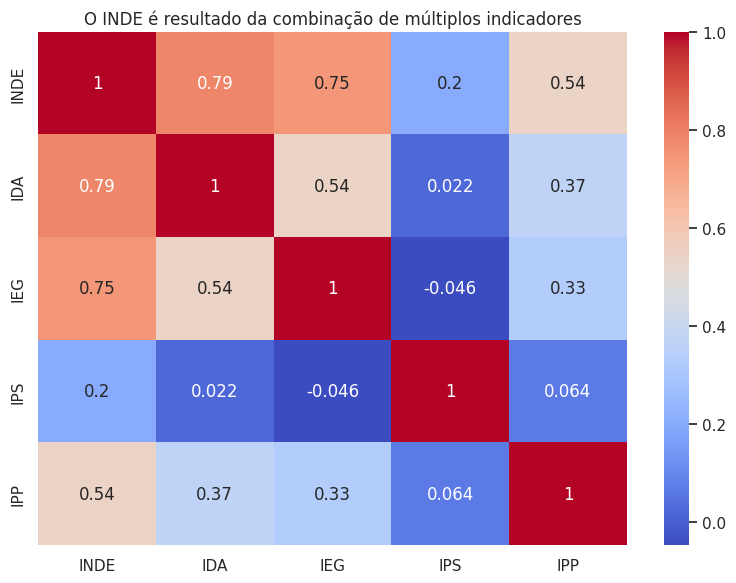

In [97]:
plt.figure(figsize=(8,6))

sns.heatmap(df[['INDE','IDA','IEG','IPS','IPP']].corr(), annot=True, cmap='coolwarm')

plt.title("O INDE é resultado da combinação de múltiplos indicadores")

plt.tight_layout()
plt.savefig("plot/inde_corr.png")
plt.show()

### Conclusão
### O INDE depende da combinação de fatores acadêmicos e comportamentais.

### **Resposta:** a multidimensionalidade é essencial.

## 9. MODELO PREDITIVO

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df['risco'] = (df['IAN'] > 3).astype(int)

X = df[['IDA','IEG','IAA','IPS','IPP']]
y = df['risco']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.50      0.07      0.12        15
           1       0.98      1.00      0.99       894

    accuracy                           0.98       909
   macro avg       0.74      0.53      0.55       909
weighted avg       0.98      0.98      0.98       909



### Conclusão
### O modelo consegue identificar alunos em risco com base nos indicadores.

### **Resposta:** é possível prever risco de defasagem.

## 10. EFETIVIDADE DO PROGRAMA

Distribuição de Pedra por ano (%):
Pedra  Ametista  Quartzo  Topázio  Ágata
Ano                                     
2022       40.5     15.3     15.1   29.1
2023       40.9      7.7     24.9   26.4
2024       37.1     10.6     30.9   21.3


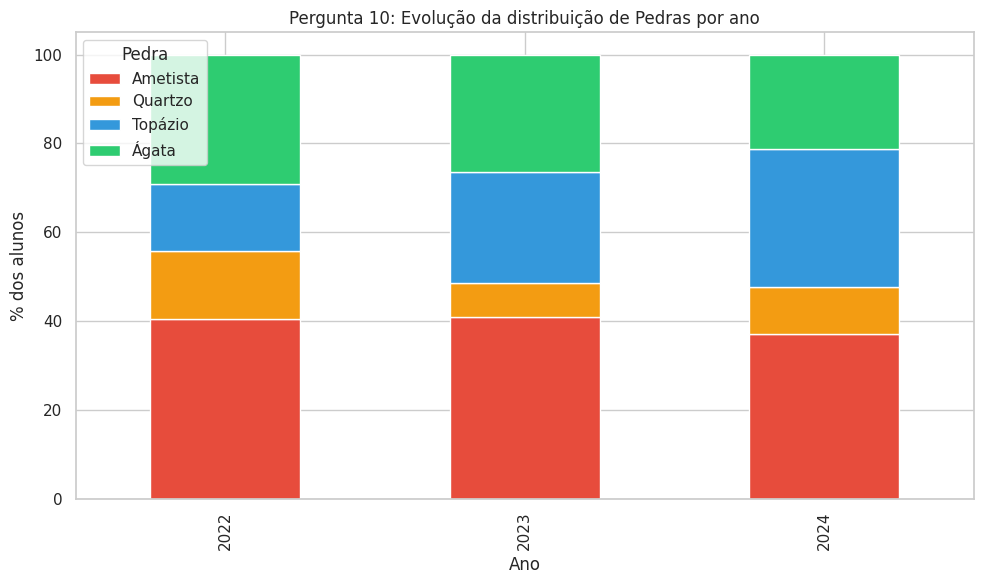


Transição 2022->2023 (570 alunos):
  Subiram de pedra:   24.4%
  Mantiveram:         51.2%
  Desceram de pedra:  24.4%

Transição 2023->2024 (678 alunos):
  Subiram de pedra:   24.2%
  Mantiveram:         50.0%
  Desceram de pedra:  25.8%


In [99]:
# Evolução de Pedra por ano (percentual)
pedra_ano = pd.crosstab(df['Ano'], df['Pedra'], normalize='index') * 100
print(f"Distribuição de Pedra por ano (%):\n{pedra_ano.round(1)}")

fig, ax = plt.subplots(figsize=(10, 6))
pedra_ano.plot(kind='bar', stacked=True, ax=ax,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
ax.set_title('Pergunta 10: Evolução da distribuição de Pedras por ano')
ax.set_ylabel('% dos alunos')
ax.set_xlabel('Ano')
ax.legend(title='Pedra')
plt.tight_layout()
plt.show()

# Para alunos rastreáveis: transição de pedra
for ano_a, ano_b in [(2022, 2023), (2023, 2024)]:
    df_a = df[df['Ano'] == ano_a][['RA', 'Pedra_Num']].rename(columns={'Pedra_Num': 'Pedra_A'})
    df_b = df[df['Ano'] == ano_b][['RA', 'Pedra_Num']].rename(columns={'Pedra_Num': 'Pedra_B'})
    merged = df_a.merge(df_b, on='RA').dropna()
    merged['Transicao'] = merged['Pedra_B'] - merged['Pedra_A']
    melhorou = (merged['Transicao'] > 0).mean() * 100
    piorou = (merged['Transicao'] < 0).mean() * 100
    manteve = (merged['Transicao'] == 0).mean() * 100
    print(f"\nTransição {ano_a}->{ano_b} ({len(merged)} alunos):")
    print(f"  Subiram de pedra:   {melhorou:.1f}%")
    print(f"  Mantiveram:         {manteve:.1f}%")
    print(f"  Desceram de pedra:  {piorou:.1f}%")

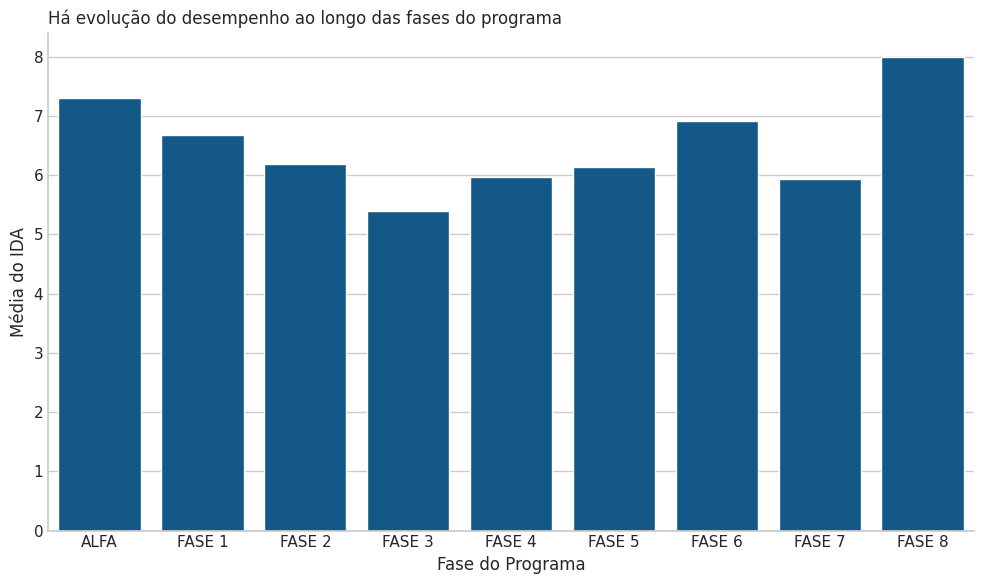

In [100]:
plt.figure(figsize=(10,6))

# Sort by Fase_Num to ensure correct ordering of phases
df_sorted = df.sort_values('Fase_Num')

sns.barplot(data=df_sorted, x='Fase', y='IDA', errorbar=None, color='#005C99') # Changed color to a darker blue

limpar_grafico()

plt.title("Há evolução do desempenho ao longo das fases do programa", loc='left')
plt.xlabel('Fase do Programa') # Adiciona legenda ao eixo X
plt.ylabel('Média do IDA')    # Adiciona legenda ao eixo Y

plt.tight_layout()
plt.savefig("plot/fases.png")
plt.show()

### Conclusão
### Há evolução ao longo das fases, indicando impacto positivo do programa.

### **Resposta:** o programa apresenta efetividade.

## 11. INSIGHTS


Médias por gênero:
            INDE    IDA    IEG   IPV
Genero                              
Feminino   7.338  6.397  8.036  7.69
Masculino  7.192  6.352  7.842  7.38


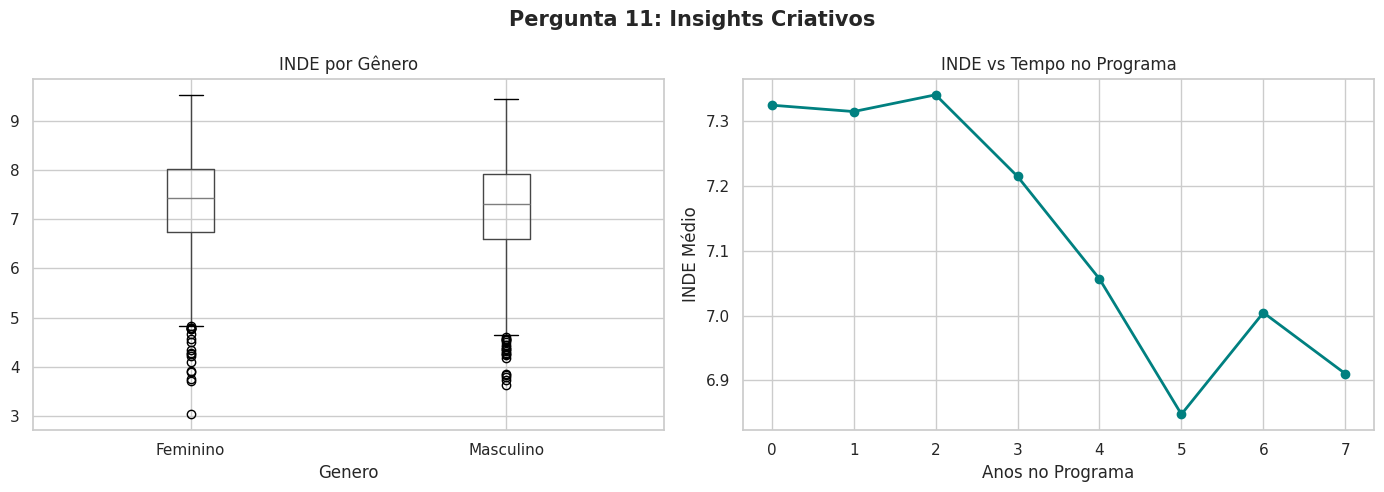


Médias por tipo de instituição:
                INDE    IDA    IEG
Privada/Outra  7.718  7.009  6.805
Pública        7.201  6.279  8.167


In [101]:
# 11a: Impacto do gênero
genero_stats = df.groupby('Genero')[['INDE', 'IDA', 'IEG', 'IPV']].mean()
print(f"\nMédias por gênero:\n{genero_stats.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='INDE', by='Genero', ax=axes[0])
axes[0].set_title('INDE por Gênero')

# 11b: Anos no programa vs desempenho
anos_prog = df.groupby('Anos_No_Programa')['INDE'].mean()
axes[1].plot(anos_prog.index, anos_prog.values, 'o-', linewidth=2, color='teal')
axes[1].set_xlabel('Anos no Programa')
axes[1].set_ylabel('INDE Médio')
axes[1].set_title('INDE vs Tempo no Programa')

plt.suptitle('Pergunta 11: Insights Criativos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 11c: Instituição pública vs privada
inst_stats = df.groupby('Instituicao_Publica')[['INDE', 'IDA', 'IEG']].mean()
inst_stats.index = ['Privada/Outra', 'Pública']
print(f"\nMédias por tipo de instituição:\n{inst_stats.round(3)}")

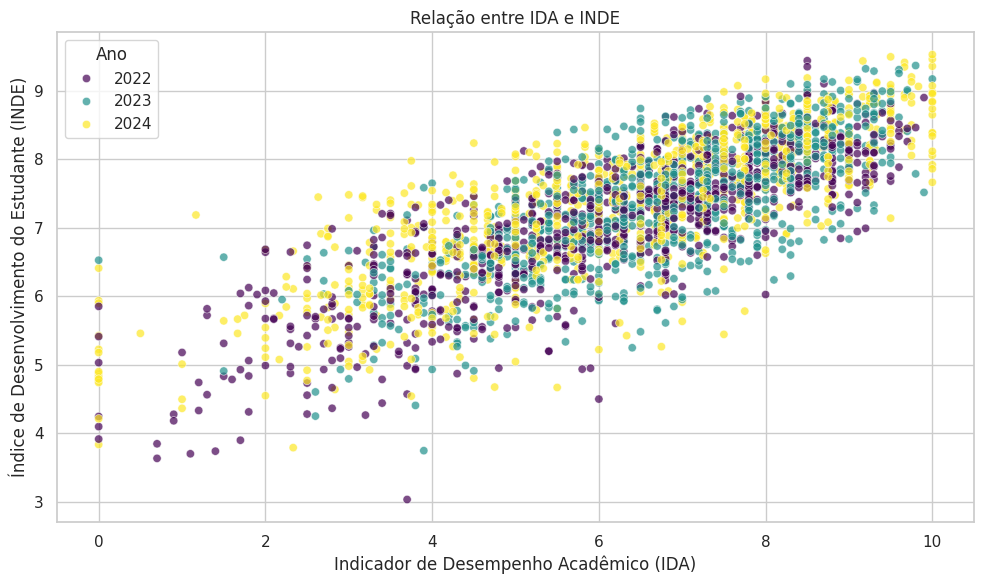

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='IDA', y='INDE', data=df, hue='Ano', palette='viridis', alpha=0.7, ax=ax)
ax.set_title('Relação entre IDA e INDE')
ax.set_xlabel('Indicador de Desempenho Acadêmico (IDA)')
ax.set_ylabel('Índice de Desenvolvimento do Estudante (INDE)')
plt.tight_layout()
plt.show()

## Insights Estratégicos

- Engajamento é o principal fator de sucesso
- Defasagem ainda exige atenção prioritária
- Fatores psicossociais impactam diretamente desempenho
- O uso de modelos preditivos pode antecipar riscos

### Recomendação
Migrar para uma abordagem orientada por dados e prevenção.

In [103]:
# Calcular tercis de IPV
df['IPV_Tercil'] = pd.qcut(df['IPV'], q=3, labels=['Baixo', 'Médio', 'Alto'])

# Agrupar por tercil e calcular a média dos indicadores
indicators = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
ipv_profile = df.groupby('IPV_Tercil')[indicators].mean()

print("Calculado ipv_profile.")

Calculado ipv_profile.


### Relação entre IDA e INDE

# **Preparação da variável-alvo**

In [104]:
# =============================================================================
# PERGUNTA 9 - PREPARAÇÃO DA VARIÁVEL-ALVO DO MODELO
# =============================================================================

df_model = df.copy()

df_model["Risco_Aluno"] = (
    (df_model["Defasagem"] < 0) |
    (df_model["IAN"] <= 5) |
    (df_model["INDE"] < 6.5)
).astype(int)

print("Distribuição da variável-alvo:")
print(df_model["Risco_Aluno"].value_counts())
print("\nDistribuição percentual:")
print((df_model["Risco_Aluno"].value_counts(normalize=True) * 100).round(2))

Distribuição da variável-alvo:
Risco_Aluno
1    1781
0    1249
Name: count, dtype: int64

Distribuição percentual:
Risco_Aluno
1    58.78
0    41.22
Name: proportion, dtype: float64


# **Seleção de features e divisão treino/teste**

In [105]:
# =============================================================================
# PERGUNTA 9 - SELEÇÃO DE FEATURES E SEPARAÇÃO TREINO/TESTE
# =============================================================================

from sklearn.model_selection import train_test_split

features = [
    "IDA", "IEG", "IAA", "IPS", "IPP", "IPV",
    "Nota_Mat", "Nota_Por", "Nota_Ing",
    "Anos_No_Programa",
    "Instituicao_Publica",
    "Avaliacao_Completa",
    "Pedra_Num",
    "Fase_Num",
    "Genero_Num"
]

target = "Risco_Aluno"

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape treino:", X_train.shape)
print("Shape teste:", X_test.shape)
print("\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True).round(3))

Shape treino: (2424, 15)
Shape teste: (606, 15)

Distribuição do target no treino:
Risco_Aluno
1    0.588
0    0.412
Name: proportion, dtype: float64

Distribuição do target no teste:
Risco_Aluno
1    0.587
0    0.413
Name: proportion, dtype: float64


# **Treinamento, avaliação e salvamento do modelo**

In [106]:
# =============================================================================
# PERGUNTA 9 - TREINAMENTO, AVALIAÇÃO E SALVAMENTO DO MODELO
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import os

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    print("\n" + "="*60)
    print(f"MODELO: {nome}")
    print("="*60)
    print(classification_report(y_test, y_pred))
    print("Matriz de confusão:")
    print(confusion_matrix(y_test, y_pred))
    print(f"ROC AUC: {auc:.4f}")

    resultados.append({
        "modelo": nome,
        "auc": auc,
        "pipeline": pipe
    })

melhor_modelo = sorted(resultados, key=lambda x: x["auc"], reverse=True)[0]

print("\n" + "="*60)
print("MELHOR MODELO")
print("="*60)
print(f"Modelo escolhido: {melhor_modelo['modelo']}")
print(f"ROC AUC: {melhor_modelo['auc']:.4f}")

MODEL_DIR = "/content/modelos"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "modelo_risco_passos_magicos.joblib")
joblib.dump(melhor_modelo["pipeline"], model_path)

print(f"\nModelo salvo em: {model_path}")


MODELO: Logistic Regression
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       250
           1       0.87      0.80      0.83       356

    accuracy                           0.81       606
   macro avg       0.80      0.81      0.81       606
weighted avg       0.81      0.81      0.81       606

Matriz de confusão:
[[206  44]
 [ 72 284]]
ROC AUC: 0.8953

MODELO: Random Forest
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       250
           1       0.85      0.89      0.87       356

    accuracy                           0.84       606
   macro avg       0.84      0.83      0.84       606
weighted avg       0.84      0.84      0.84       606

Matriz de confusão:
[[193  57]
 [ 38 318]]
ROC AUC: 0.9225

MODELO: Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       250
           1       0.85      0.89      0